In [1]:
"""
Churn Exploratory Data Analysis (EDA)

Goal:
- Understand churn distribution
- Identify key patterns and drivers of churn
"""

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
"""
Load standardized churn dataset.
"""

churn_df = pd.read_csv("../data/interim/bank_churn_standardized.csv")

churn_df.head()

,rownumber,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
"""
Quick dataset overview.
"""

print("Shape:", churn_df.shape)
churn_df.info()

Shape: (10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rownumber        10000 non-null  int64  
 1   customerid       10000 non-null  int64  
 2   surname          10000 non-null  object 
 3   creditscore      10000 non-null  int64  
 4   geography        10000 non-null  object 
 5   gender           10000 non-null  object 
 6   age              10000 non-null  int64  
 7   tenure           10000 non-null  int64  
 8   balance          10000 non-null  float64
 9   numofproducts    10000 non-null  int64  
 10  hascrcard        10000 non-null  int64  
 11  isactivemember   10000 non-null  int64  
 12  estimatedsalary  10000 non-null  float64
 13  exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


exited
0    7963
1    2037
Name: count, dtype: int64


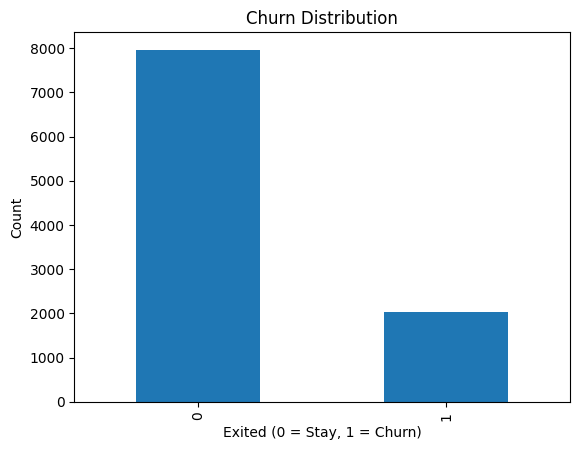

In [4]:
"""
Check how many customers churned vs stayed.
"""

churn_counts = churn_df["exited"].value_counts()
print(churn_counts)

# Plot
churn_counts.plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Exited (0 = Stay, 1 = Churn)")
plt.ylabel("Count")
plt.show()

In [5]:
"""
Check churn percentage.
"""

churn_pct = churn_df["exited"].value_counts(normalize=True) * 100
print(churn_pct)

exited
0    79.63
1    20.37
Name: proportion, dtype: float64


In [6]:
"""
Compare age between churned and non-churned customers.
"""

churn_df.groupby("exited")["age"].mean()

exited
0    37.408389
1    44.837997
Name: age, dtype: float64

In [7]:
"""
Compare account balance.
"""

churn_df.groupby("exited")["balance"].mean()

exited
0    72745.296779
1    91108.539337
Name: balance, dtype: float64

In [8]:
"""
Check how number of products affects churn.
"""

churn_df.groupby("numofproducts")["exited"].mean()

numofproducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: exited, dtype: float64

In [9]:
"""
Check impact of activity status.
"""

churn_df.groupby("isactivemember")["exited"].mean()

isactivemember
0    0.268509
1    0.142691
Name: exited, dtype: float64

In [10]:
"""
Churn rate by geography.
"""

churn_df.groupby("geography")["exited"].mean()

geography
France     0.161548
Germany    0.324432
Spain      0.166734
Name: exited, dtype: float64

In [11]:
"""
Churn rate by gender.
"""

churn_df.groupby("gender")["exited"].mean()

gender
Female    0.250715
Male      0.164559
Name: exited, dtype: float64

In [12]:
"""
Summarize key findings from EDA.
"""

insights = [
    "Churn rate is approximately X%",
    "Older customers show higher churn",
    "Inactive members churn significantly more",
    "Customers with fewer products are more likely to churn",
    "Geography influences churn behavior"
]

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")

1. Churn rate is approximately X%
2. Older customers show higher churn
3. Inactive members churn significantly more
4. Customers with fewer products are more likely to churn
5. Geography influences churn behavior
